### Features Preparation

Merge the 1st hour Flow DTCWPT PC features to the df_combined file

In [27]:
# Import necessary libraries
import pandas as pd

# Load df_combined dataset from Sheet5
df_combined = pd.read_excel(
    '/nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/TRAPPARDS/df_combined.xlsx', 
    sheet_name='Sheet5'
)
print("Loaded df_combined from Sheet5:")
display(df_combined.head())

# Load Flow_DTCWPT_PCA_Features dataset
df_pca_features = pd.read_excel(
    '/nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/TRAPPARDS/WaveformData/01_Waveform_Raw_248_1st/TWs_243_1st/Flow_DTCWPT(Level_3)/Flow_DTCWPT_Features(Level_3)/Flow_DTCWPT_PCA_Features.xlsx'
)
print("Loaded df_pca_features:")
display(df_pca_features.head())

# Customize File_Name to extract the common part, removing "_Flow_DTCWPT_Features" but keeping ".csv"
df_pca_features['File_Name_Common'] = df_pca_features['File_Name'].str.replace('_Flow_DTCWPT_Features', '', regex=False)
print("Customized File_Name to match with FileName_Waveform_1st:")
display(df_pca_features[['File_Name', 'File_Name_Common']].head())

# Select only PC1 to PC8 columns and the customized filename column for merging
df_pca_features = df_pca_features[['File_Name_Common', 'PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8']]

# Merge based on the matching filename columns
df_merged = pd.merge(df_combined, df_pca_features, left_on='FileName_Waveform_1st', right_on='File_Name_Common', how='left')

# Drop the extra File_Name_Common column if not needed
df_merged = df_merged.drop(columns=['File_Name_Common'])
print("Merged DataFrame with PC1 to PC8 added:")
display(df_merged.head())

# Save the merged DataFrame as a new sheet, Sheet6, in the original df_combined.xlsx file
with pd.ExcelWriter('/nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/TRAPPARDS/df_combined.xlsx', mode='a', engine='openpyxl') as writer:
    df_merged.to_excel(writer, sheet_name='Sheet6', index=False)
print("Merged DataFrame saved to 'Sheet6' in the original df_combined.xlsx file.")


Merge the 1st hour OSI mean to the df_combined

In [2]:
# Import necessary libraries
import pandas as pd
import os

# Load df_combined dataset from Sheet16
df_combined = pd.read_excel(
    '/nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/TRAPPARDS/df_combined.xlsx', 
    sheet_name='Sheet16'
)
# print("Loaded df_combined from Sheet16:")
# display(df_combined.head())

# Path to the directory containing the CSV files
csv_directory = "/nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/TRAPPARDS/VitalData/01_Vital_Raw_282_1st/OSI_285_1st/TWs_284_1st/PEEP_Settings_284_1st/Abnormal_Detection_282_1st"

# Loop through all the CSV files in the directory
for file_name in os.listdir(csv_directory):
    if file_name.endswith(".csv"):  # Only process CSV files
        file_path = os.path.join(csv_directory, file_name)
        # print(f"Processing file: {file_name}")

        # Read the CSV file
        df_csv = pd.read_csv(file_path)
        
        # Extract OSI_1st_avg and calculate OSI_1st_std
        osi_avg_value = df_csv['OSI_1st_avg'].iloc[0]  # Get the first value (assuming it's constant)
        osi_mean_value = df_csv['OSI'].mean()  # Calculate the mean
        osi_std_value = df_csv['OSI'].std()  # Calculate the standard deviation
        
        # Find the matching row in df_combined based on FileName_Vital_1st
        matching_row_index = df_combined[df_combined['FileName_Vital_1st'] == file_name].index
        
        if not matching_row_index.empty:  # If there is a matching row
            # Assign OSI_1st_avg and OSI_1st_std values to the corresponding row in df_combined
            df_combined.loc[matching_row_index, 'OSI_1st_avg'] = osi_avg_value
            df_combined.loc[matching_row_index, 'OSI_1st_mean'] = osi_mean_value
            df_combined.loc[matching_row_index, 'OSI_1st_std'] = osi_std_value
            # print(f"Added OSI_1st_avg and OSI_1st_std values for file {file_name}")
        else:
            print(f"No match found for {file_name} in FileName_Vital_1st column")

# Save the updated df_combined back to Sheet17 in the original file
with pd.ExcelWriter('/nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/TRAPPARDS/df_combined.xlsx', mode='a', engine='openpyxl') as writer:
    df_combined.to_excel(writer, sheet_name='Sheet17', index=False)

# print("Updated df_combined with OSI_1st_avg and OSI_1st_std values saved to 'Sheet17'.")


Merge the 12th hour OSI mean to the df_combined

In [31]:
# Import necessary libraries
import pandas as pd
import os

# Load df_combined dataset from Sheet7
df_combined = pd.read_excel(
    '/nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/TRAPPARDS/df_combined.xlsx', 
    sheet_name='Sheet7'
)
print("Loaded df_combined from Sheet7:")
display(df_combined.head())

# Path to the directory containing the CSV files
csv_directory = "/nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/TRAPPARDS/VitalData/02_Vital_Raw_226_12th/OSI_258_12th/TWs_258_12th"

# Loop through all the CSV files in the directory
for file_name in os.listdir(csv_directory):
    if file_name.endswith(".csv"):  # Only process CSV files
        file_path = os.path.join(csv_directory, file_name)
        print(f"Processing file: {file_name}")

        # Read the CSV file
        df_csv = pd.read_csv(file_path)
        
        # Extract the OSI_1st_avg value from the CSV file (assuming the value is constant across the file)
        ### There is a typo in the original csv files that it stored 12th hour's OSI mean but the column name was written as 'OSI_1st_avg'.
        osi_avg_value = df_csv['OSI_1st_avg'].iloc[0]  # Get the first value (assuming the value is the same for all rows)
               
        # Find the matching row in df_combined based on FileName_Vital_12th
        matching_row_index = df_combined[df_combined['FileName_Vital_12th'] == file_name].index
        
        if not matching_row_index.empty:  # If there is a matching row
            # Assign the 12th hour OSI mean value to the corresponding row in df_combined
            df_combined.loc[matching_row_index, 'OSI_12th_avg'] = osi_avg_value
            print(f"Added OSI_12th_avg value for file {file_name}")
        else:
            print(f"No match found for {file_name} in FileName_Vital_12th column")

# Save the updated df_combined back to Sheet8 in the original file
with pd.ExcelWriter('/nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/TRAPPARDS/df_combined.xlsx', mode='a', engine='openpyxl') as writer:
    df_combined.to_excel(writer, sheet_name='Sheet8', index=False)

print("Updated df_combined with OSI_12th_avg values saved to 'Sheet8'.")


Loaded df_combined from Sheet7:


,PID,MRN,Age,Weight,1st_Time_Start,1st_Time_Stop,12th_Time_Start,12th_Time_Stop,FileName,Vent_Type,...,PEEP_Settings_1st_8,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,OSI_1st_avg
0,1288,101607118,0.828285,437.04,2023-11-01 08:36:01,2023-11-01 09:36:01,2023-11-01 20:36:01,2023-11-01 21:36:01,Vitals_6hrsBefore_18hrsAfter(707).csv,CDGR,...,NaN,3.979039e-13,-1.243450e-14,-2.629841e-15,5.384582e-15,-1.421085e-14,-2.664535e-15,9.103829e-15,1.987993e-14,3.517475
1,1288,101607118,0.828285,437.04,2023-12-01 11:47:45,2023-12-01 12:47:45,2023-12-01 23:47:45,2023-12-02 00:47:45,Vitals_6hrsBefore_18hrsAfter(708).csv,CDGR,...,NaN,0.000000e+00,1.110223e-14,3.386180e-15,8.881784e-16,-2.053913e-15,2.220446e-16,-1.110223e-15,5.227074e-16,6.515445
2,1293,101666704,0.409113,NaN,2023-08-01 09:03:01,2023-08-01 10:03:01,2023-08-01 21:03:01,2023-08-01 22:03:01,Vitals_6hrsBefore_18hrsAfter(808).csv,CDGR,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.551114
3,1293,101666704,0.409113,NaN,2023-09-01 04:26:00,2023-09-01 05:26:00,2023-09-01 16:26:00,2023-09-01 17:26:00,Vitals_6hrsBefore_18hrsAfter(809).csv,CDGR,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.962337
4,1748,101643395,1.277937,444.45,2023-09-23 20:34:46,2023-09-23 21:34:46,2023-09-24 08:34:46,2023-09-24 09:34:46,Vitals_6hrsBefore_18hrsAfter(712).csv,CDGR,...,NaN,9.663381e-13,-7.993606e-14,4.274359e-15,2.942091e-15,-4.440892e-15,-5.329071e-15,-2.442491e-15,1.143356e-14,6.097310


Processing file: 1035951_20231230_06_Vital_12th.csv
Added OSI_12th_avg value for file 1035951_20231230_06_Vital_12th.csv
Processing file: 536319_20240107_07_Vital_12th.csv
Added OSI_12th_avg value for file 536319_20240107_07_Vital_12th.csv
Processing file: 84839_20240226_01_Vital_12th.csv
Added OSI_12th_avg value for file 84839_20240226_01_Vital_12th.csv
Processing file: 890374_20230914_02_Vital_12th.csv
Added OSI_12th_avg value for file 890374_20230914_02_Vital_12th.csv
Processing file: 1154740_20240331_12_Vital_12th.csv
Added OSI_12th_avg value for file 1154740_20240331_12_Vital_12th.csv
Processing file: 1011066_20240201_17_Vital_12th.csv
Added OSI_12th_avg value for file 1011066_20240201_17_Vital_12th.csv
Processing file: 124851_20230919_01_Vital_12th.csv
Added OSI_12th_avg value for file 124851_20230919_01_Vital_12th.csv
Processing file: 938475_20231025_00_Vital_12th.csv
Added OSI_12th_avg value for file 938475_20231025_00_Vital_12th.csv
Processing file: 327496_20230919_11_Vital_12

Merge the 1st hour PIP mean, PIP sd, PEEP mean, and PEEP sd to the df_combined

In [1]:
# Import necessary libraries
import pandas as pd
import os

# Load df_combined dataset from Sheet13
df_combined = pd.read_excel(
    '/nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/TRAPPARDS/df_combined.xlsx', 
    sheet_name='Sheet13'
)
print("Loaded df_combined from Sheet13:")
display(df_combined.head())

# Path to the directory containing the CSV files
csv_directory = "/nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/TRAPPARDS/VitalData/01_Vital_Raw_282_1st/OSI_285_1st/TWs_284_1st/PEEP_Settings_284_1st/Abnormal_Detection_282_1st"

# Define PIP and PEEP column names to check
pip_columns = ["CDGR - PIP", "AVEA - PIP", "SVU - PIP"]
peep_columns = ["CDGR - PEEP", "AVEA - PEEP", "SVU - PEEP"]

# Loop through all the CSV files in the directory
for file_name in os.listdir(csv_directory):
    if file_name.endswith(".csv"):  # Only process CSV files
        file_path = os.path.join(csv_directory, file_name)
        print(f"Processing file: {file_name}")

        # Read the CSV file
        df_csv = pd.read_csv(file_path)
        
        # Identify the valid PIP and PEEP columns
        pip_column = next((col for col in pip_columns if col in df_csv.columns and not df_csv[col].isnull().all()), None)
        peep_column = next((col for col in peep_columns if col in df_csv.columns and not df_csv[col].isnull().all()), None)
        
        if pip_column is None or peep_column is None:
            print(f"Skipping file {file_name}: No valid PIP or PEEP columns found.")
            continue

        # Convert "CDGR - PIP" or "CDGR - PEEP" columns to cmH₂O if present
        if pip_column == "CDGR - PIP":
            df_csv[pip_column] *= 1.01972
        if peep_column == "CDGR - PEEP":
            df_csv[peep_column] *= 1.01972

        # Calculate mean and standard deviation for PIP and PEEP
        pip_mean = df_csv[pip_column].mean()
        pip_sd = df_csv[pip_column].std()
        peep_mean = df_csv[peep_column].mean()
        peep_sd = df_csv[peep_column].std()

        # Find the matching row in df_combined based on FileName_Vital_1st
        matching_row_index = df_combined[df_combined['FileName_Vital_1st'] == file_name].index
        
        if not matching_row_index.empty:  # If there is a matching row
            # Assign calculated values to the corresponding row in df_combined
            df_combined.loc[matching_row_index, 'PIP_mean'] = pip_mean
            df_combined.loc[matching_row_index, 'PIP_sd'] = pip_sd
            df_combined.loc[matching_row_index, 'PEEP_mean'] = peep_mean
            df_combined.loc[matching_row_index, 'PEEP_sd'] = peep_sd
            print(f"Added PIP and PEEP statistics for file {file_name}")
        else:
            print(f"No match found for {file_name} in FileName_Vital_1st column")

# Save the updated df_combined back to Sheet14 in the original file
with pd.ExcelWriter('/nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/TRAPPARDS/df_combined.xlsx', mode='a', engine='openpyxl') as writer:
    df_combined.to_excel(writer, sheet_name='Sheet14', index=False)

print("Updated df_combined with PIP and PEEP statistics saved to 'Sheet14'.")


Loaded df_combined from Sheet13:


,PID,MRN,DOB,Age,Age_New_Year,Weight,Weight_Pounds,Weight_Kg,Avg_Weight_Kg,avg_eVT,...,SD Sub-band 11,SD Sub-band 12,SD Sub-band 13,SD Sub-band 14,SD Sub-band 15,SD Sub-band 16,Mean Duration (s),SD Duration (s),Mean Time Difference (s),SD Time Difference (s)
0,1288,101607118,2022-06-15 11:48:00,0.828285,1.46,437.04,27.315000,12.389865,10.40,0.17,...,0.065525,0.070145,0.059961,0.061845,0.062662,0.064620,0.466278,0.251972,0.865261,0.426216
1,1288,101607118,2022-06-15 11:48:00,0.828285,1.38,437.04,27.315000,12.389865,9.84,52.64,...,0.230574,0.207121,0.288267,0.290030,0.257201,0.284228,0.818333,0.265002,1.326698,0.387242
2,1293,101666704,2022-09-21 00:00:00,0.409113,0.86,NaN,0.000000,0.000000,7.30,25.05,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1293,101666704,2022-09-21 00:00:00,0.409113,0.94,NaN,0.000000,0.000000,7.40,40.45,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1748,101643395,2022-06-14 00:00:00,1.277937,1.69,444.45,27.778125,12.599935,12.90,73.19,...,0.213681,0.221088,0.221991,0.224974,0.214753,0.224563,0.919952,0.596776,1.437277,0.715040


Processing file: 802274_20230901_06_Vital_1st.csv
Added PIP and PEEP statistics for file 802274_20230901_06_Vital_1st.csv
Processing file: 522290_20240606_12_Vital_1st.csv
Added PIP and PEEP statistics for file 522290_20240606_12_Vital_1st.csv
Processing file: 1134621_20240418_17_Vital_1st.csv
Added PIP and PEEP statistics for file 1134621_20240418_17_Vital_1st.csv
Processing file: 875186_20231102_05_Vital_1st.csv
Added PIP and PEEP statistics for file 875186_20231102_05_Vital_1st.csv
Processing file: 228289_20240430_02_Vital_1st.csv
Added PIP and PEEP statistics for file 228289_20240430_02_Vital_1st.csv
Processing file: 58546_20230925_17_Vital_1st.csv
Added PIP and PEEP statistics for file 58546_20230925_17_Vital_1st.csv
Processing file: 1002213_20231128_14_Vital_1st.csv
Added PIP and PEEP statistics for file 1002213_20231128_14_Vital_1st.csv
Processing file: 1293_20230901_04_Vital_1st.csv
Added PIP and PEEP statistics for file 1293_20230901_04_Vital_1st.csv
Processing file: 606288_20

Merge the 1st hour Flow DTCWPT energy features to the df_combined file

In [4]:
# Import necessary libraries
import pandas as pd

# Load df_combined dataset from Sheet14
df_combined = pd.read_excel(
    '/nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/TRAPPARDS/df_combined.xlsx', 
    sheet_name='Sheet14'
)
print("Loaded df_combined from Sheet14:")
display(df_combined.head())

# Load Energy_Results dataset
df_energy_features = pd.read_excel(
    '/nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/TRAPPARDS/WaveformData/01_Waveform_Raw_248_1st/TWs_243_1st/Abnormal_Detection_242_1st/Flow_DTCWPT(Level_4)/Flow_DTCWPT_Features(Level_4)/Energy_Results.xlsx'
)
print("Loaded Energy_Results:")
display(df_energy_features.head())

# Customize File_Name to extract the common part, removing "_Flow_DTCWPT_Features" but keeping ".csv"
df_energy_features['File_Name_Common'] = df_energy_features['File Name'].str.replace('_Flow_DTCWPT_Features', '', regex=False)
print("Customized File_Name to match with FileName_Waveform_1st:")
display(df_energy_features[['File Name', 'File_Name_Common']].head())

# Select "Sub-band Energy", "Normalized Energy", "Mean Sub-band", and "SD Sub-band" columns and the customized filename column for merging
columns_to_merge = ['File_Name_Common'] + [f'Sub-band Energy {i}' for i in range(1, 17)] + [f'Normalized Energy {i}' for i in range(1, 17)] + [f'Mean Sub-band {i}' for i in range(1, 17)] + [f'SD Sub-band {i}' for i in range(1, 17)]  
df_energy_features = df_energy_features[columns_to_merge]

# Merge based on the matching filename columns
df_merged = pd.merge(df_combined, df_energy_features, left_on='FileName_Waveform_1st', right_on='File_Name_Common', how='left')

# Drop the extra File_Name_Common column if not needed
df_merged = df_merged.drop(columns=['File_Name_Common'])
print("Merged DataFrame with Normalized Energy 1 to Normalized Energy 16 added:")
display(df_merged.head())

# Save the merged DataFrame as a new sheet, Sheet15, in the original df_combined.xlsx file
with pd.ExcelWriter('/nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/TRAPPARDS/df_combined.xlsx', mode='a', engine='openpyxl') as writer:
    df_merged.to_excel(writer, sheet_name='Sheet15', index=False)
print("Merged DataFrame saved to 'Sheet15' in the original df_combined.xlsx file.")


Loaded df_combined from Sheet14:


,PID,MRN,DOB,Age,Age_New_Year,Weight,Weight_Pounds,Weight_Kg,Avg_Weight_Kg,avg_eVT,...,PC5,PC6,PC7,PC8,OSI_1st_avg,OSI_12th_avg,PIP_mean,PIP_sd,PEEP_mean,PEEP_sd
0,1288,101607118,2022-06-15 11:48:00,0.828285,1.46,437.04,27.315000,12.389865,10.40,0.17,...,-2.053913e-15,2.220446e-16,-1.110223e-15,5.227074e-16,6.515445,6.633780,10.756281,0.517410,10.180929,0.116858
1,1288,101607118,2022-06-15 11:48:00,0.828285,1.38,437.04,27.315000,12.389865,9.84,52.64,...,-1.421085e-14,-2.664535e-15,9.103829e-15,1.987993e-14,3.517475,3.302584,24.475276,0.294145,7.950697,0.377498
2,1293,101666704,2022-09-21 00:00:00,0.409113,0.86,NaN,0.000000,0.000000,7.30,25.05,...,NaN,NaN,NaN,NaN,5.551114,9.471001,27.699030,0.881207,7.279047,0.500959
3,1293,101666704,2022-09-21 00:00:00,0.409113,0.94,NaN,0.000000,0.000000,7.40,40.45,...,NaN,NaN,NaN,NaN,7.962337,6.048559,30.982670,0.646084,10.077374,0.279715
4,1748,101643395,2022-06-14 00:00:00,1.277937,1.69,444.45,27.778125,12.599935,12.90,73.19,...,-7.105427e-15,-2.220446e-15,-1.243450e-14,7.391223e-15,6.110500,3.701600,25.466164,3.350376,7.798639,1.169066


Loaded Energy_Results:


,File Name,Sub-band Energy 1,Sub-band Energy 2,Sub-band Energy 3,Sub-band Energy 4,Sub-band Energy 5,Sub-band Energy 6,Sub-band Energy 7,Sub-band Energy 8,Sub-band Energy 9,...,SD Sub-band 7,SD Sub-band 8,SD Sub-band 9,SD Sub-band 10,SD Sub-band 11,SD Sub-band 12,SD Sub-band 13,SD Sub-band 14,SD Sub-band 15,SD Sub-band 16
0,161628_20230916_18_Waveform_1st_Flow_DTCWPT_Fe...,2.809631e+08,1.557323e+06,41267.855715,145614.409446,7378.876837,7721.226055,14284.661124,8392.113083,3605.243471,...,0.574783,0.440570,0.288765,0.309880,0.272086,0.258166,0.338185,0.346109,0.297399,0.290100
1,901729_20240118_17_Waveform_1st_Flow_DTCWPT_Fe...,1.803580e+08,1.089805e+06,38474.802469,134540.776281,6098.409947,6545.314301,13695.529722,8872.474485,2674.196622,...,0.562854,0.453032,0.248716,0.270552,0.280067,0.285905,0.308778,0.312691,0.296493,0.311194
2,235919_20240101_05_Waveform_1st_Flow_DTCWPT_Fe...,5.776955e+07,6.055216e+05,23161.274056,83693.264182,3596.552922,4216.560583,9501.927019,5534.108530,1147.039582,...,0.468900,0.357859,0.162921,0.186667,0.198014,0.190838,0.244531,0.246388,0.213923,0.235702
3,1009659_20231201_16_Waveform_1st_Flow_DTCWPT_F...,5.570038e+07,4.559620e+05,16837.276366,66450.675098,3230.092490,3759.522265,7289.714054,4816.661070,891.359418,...,0.411224,0.334275,0.143799,0.168906,0.193792,0.177053,0.233589,0.230546,0.201266,0.226324
4,908466_20240525_22_Waveform_1st_Flow_DTCWPT_Fe...,1.241502e+07,1.890882e+05,18369.316713,48649.684035,2035.730637,2756.612087,9358.341885,4537.892800,411.434410,...,0.463949,0.323088,0.097285,0.116155,0.160451,0.138089,0.194141,0.195760,0.172413,0.184441


Customized File_Name to match with FileName_Waveform_1st:


,File Name,File_Name_Common
0,161628_20230916_18_Waveform_1st_Flow_DTCWPT_Fe...,161628_20230916_18_Waveform_1st.csv
1,901729_20240118_17_Waveform_1st_Flow_DTCWPT_Fe...,901729_20240118_17_Waveform_1st.csv
2,235919_20240101_05_Waveform_1st_Flow_DTCWPT_Fe...,235919_20240101_05_Waveform_1st.csv
3,1009659_20231201_16_Waveform_1st_Flow_DTCWPT_F...,1009659_20231201_16_Waveform_1st.csv
4,908466_20240525_22_Waveform_1st_Flow_DTCWPT_Fe...,908466_20240525_22_Waveform_1st.csv


Merged DataFrame with Normalized Energy 1 to Normalized Energy 16 added:


,PID,MRN,DOB,Age,Age_New_Year,Weight,Weight_Pounds,Weight_Kg,Avg_Weight_Kg,avg_eVT,...,SD Sub-band 7,SD Sub-band 8,SD Sub-band 9,SD Sub-band 10,SD Sub-band 11,SD Sub-band 12,SD Sub-band 13,SD Sub-band 14,SD Sub-band 15,SD Sub-band 16
0,1288,101607118,2022-06-15 11:48:00,0.828285,1.46,437.04,27.315000,12.389865,10.40,0.17,...,0.141854,0.103887,0.056886,0.067883,0.068454,0.073270,0.063966,0.067118,0.066092,0.067273
1,1288,101607118,2022-06-15 11:48:00,0.828285,1.38,437.04,27.315000,12.389865,9.84,52.64,...,0.587355,0.443154,0.170300,0.205824,0.237080,0.217354,0.298765,0.302635,0.267791,0.298575
2,1293,101666704,2022-09-21 00:00:00,0.409113,0.86,NaN,0.000000,0.000000,7.30,25.05,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1293,101666704,2022-09-21 00:00:00,0.409113,0.94,NaN,0.000000,0.000000,7.40,40.45,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1748,101643395,2022-06-14 00:00:00,1.277937,1.69,444.45,27.778125,12.599935,12.90,73.19,...,0.563258,0.422682,0.195163,0.222642,0.230841,0.231746,0.241115,0.240899,0.229708,0.241669


Merged DataFrame saved to 'Sheet15' in the original df_combined.xlsx file.


Merge the 1st hour Flow time domain features to the df_combined file

In [5]:
# Import necessary libraries
import pandas as pd

# Load df_combined dataset from Sheet15
df_combined = pd.read_excel(
    '/nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/TRAPPARDS/df_combined.xlsx', 
    sheet_name='Sheet15'
)
print("Loaded df_combined from Sheet15:")
display(df_combined.head())

# Load Negative_Duration_Results dataset
df_time_domain_features = pd.read_excel(
    '/nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/TRAPPARDS/WaveformData/01_Waveform_Raw_248_1st/TWs_243_1st/Abnormal_Detection_242_1st/Negative_Duration_Results.xlsx'
)
print("Loaded Negative_Duration_Results:")
display(df_time_domain_features.head())

# Select only the relevant columns for merging
columns_to_merge = ['File Name', 'Mean Duration (s)', 'SD Duration (s)', 'Mean Time Difference (s)', 'SD Time Difference (s)']
df_time_domain_features = df_time_domain_features[columns_to_merge]

# Merge based on the matching filename columns
df_merged = pd.merge(df_combined, df_time_domain_features, left_on='FileName_Waveform_1st', right_on='File Name', how='left')

print("Merged DataFrame with time domain features added:")
display(df_merged.head())

# Save the merged DataFrame as a new sheet, Sheet16, in the original df_combined.xlsx file
with pd.ExcelWriter('/nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/TRAPPARDS/df_combined.xlsx', mode='a', engine='openpyxl') as writer:
    df_merged.to_excel(writer, sheet_name='Sheet16', index=False)
print("Merged DataFrame saved to 'Sheet16' in the original df_combined.xlsx file.")


Loaded df_combined from Sheet15:


,PID,MRN,DOB,Age,Age_New_Year,Weight,Weight_Pounds,Weight_Kg,Avg_Weight_Kg,avg_eVT,...,SD Sub-band 7,SD Sub-band 8,SD Sub-band 9,SD Sub-band 10,SD Sub-band 11,SD Sub-band 12,SD Sub-band 13,SD Sub-band 14,SD Sub-band 15,SD Sub-band 16
0,1288,101607118,2022-06-15 11:48:00,0.828285,1.46,437.04,27.315000,12.389865,10.40,0.17,...,0.141854,0.103887,0.056886,0.067883,0.068454,0.073270,0.063966,0.067118,0.066092,0.067273
1,1288,101607118,2022-06-15 11:48:00,0.828285,1.38,437.04,27.315000,12.389865,9.84,52.64,...,0.587355,0.443154,0.170300,0.205824,0.237080,0.217354,0.298765,0.302635,0.267791,0.298575
2,1293,101666704,2022-09-21 00:00:00,0.409113,0.86,NaN,0.000000,0.000000,7.30,25.05,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1293,101666704,2022-09-21 00:00:00,0.409113,0.94,NaN,0.000000,0.000000,7.40,40.45,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1748,101643395,2022-06-14 00:00:00,1.277937,1.69,444.45,27.778125,12.599935,12.90,73.19,...,0.563258,0.422682,0.195163,0.222642,0.230841,0.231746,0.241115,0.240899,0.229708,0.241669


Loaded Negative_Duration_Results:


,File Name,Target Column,Mean Duration (s),SD Duration (s),Mean Time Difference (s),SD Time Difference (s)
0,867410_20231226_18_Waveform_1st.csv,CDGR - Flow,0.248969,0.182429,0.573503,0.399043
1,1198474_20240501_01_Waveform_1st.csv,CDGR - Flow,0.458664,0.204045,0.906522,0.389250
2,1288_20231201_11_Waveform_1st.csv,CDGR - Flow,0.465142,0.252641,0.877709,0.442218
3,354894_20240427_11_Waveform_1st.csv,CDGR - Flow,0.842699,0.566539,1.445253,0.864027
4,606288_20231016_22_Waveform_1st.csv,CDGR - Flow,2.052593,0.898153,2.718984,1.047853


Merged DataFrame with time domain features added:


,PID,MRN,DOB,Age,Age_New_Year,Weight,Weight_Pounds,Weight_Kg,Avg_Weight_Kg,avg_eVT,...,SD Sub-band 12,SD Sub-band 13,SD Sub-band 14,SD Sub-band 15,SD Sub-band 16,File Name,Mean Duration (s),SD Duration (s),Mean Time Difference (s),SD Time Difference (s)
0,1288,101607118,2022-06-15 11:48:00,0.828285,1.46,437.04,27.315000,12.389865,10.40,0.17,...,0.073270,0.063966,0.067118,0.066092,0.067273,1288_20231201_11_Waveform_1st.csv,0.465142,0.252641,0.877709,0.442218
1,1288,101607118,2022-06-15 11:48:00,0.828285,1.38,437.04,27.315000,12.389865,9.84,52.64,...,0.217354,0.298765,0.302635,0.267791,0.298575,1288_20231101_08_Waveform_1st.csv,0.813054,0.275137,1.340045,0.416391
2,1293,101666704,2022-09-21 00:00:00,0.409113,0.86,NaN,0.000000,0.000000,7.30,25.05,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1293,101666704,2022-09-21 00:00:00,0.409113,0.94,NaN,0.000000,0.000000,7.40,40.45,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1748,101643395,2022-06-14 00:00:00,1.277937,1.69,444.45,27.778125,12.599935,12.90,73.19,...,0.231746,0.241115,0.240899,0.229708,0.241669,1748_20240221_02_Waveform_1st.csv,0.911205,0.597395,1.448528,0.728862


Merged DataFrame saved to 'Sheet16' in the original df_combined.xlsx file.


Machine Learning models:

Classification Models

Approach:
1. Data Splitting:

    - Keep approximately 60 samples in the test set, ensuring the class ratio of 187:38 (mild:other) is maintained.
    - The remaining samples go into the training set.

2. Repeated Resampling for Validation:

    - Resample and shuffle the training set 15 times.
    - For each resample:
        - Select around 80 samples, maintaining the class ratio (55 mild, 25 other).
        - Train the models on this subset and tune hyperparameters using cross-validation within this subset.

3. Validation and Testing:

    - Evaluate each model on the test set after training on each resample.
    - Collect metrics (AUC, AUPRC, F1) for the test set across all 15 resamples.

4. Reporting:

    - Calculate the mean and standard deviation for AUC, AUPRC, and F1 across the 15 resamples for each model.
    - Report the best hyperparameters for each model.

In [2]:
import pandas as pd
from sklearn.feature_selection import mutual_info_regression
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load the Excel sheet
df_combined = pd.read_excel(
    '/nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/TRAPPARDS/df_combined.xlsx',
    sheet_name='Sheet18'
)

# Define the columns of interest
subband_energy_columns = [f"Sub-band Energy {i}" for i in range(1, 17)]  # Sub-band Energy 1 to 16
target_column = "OSI_12th_avg"

# Ensure all required columns are present
missing_columns = [col for col in subband_energy_columns + [target_column] if col not in df_combined.columns]
if missing_columns:
    raise ValueError(f"Missing columns in the dataset: {missing_columns}")

# Extract features and target
X = df_combined[subband_energy_columns]
y = df_combined[target_column]

# Handle NaN values by dropping rows
combined_data = pd.concat([X, y], axis=1).dropna()
X = combined_data[subband_energy_columns]
y = combined_data[target_column]

# Compute mutual information between each feature and the target
mi_scores = mutual_info_regression(X, y)

# Normalize mutual information scores to rank their relevance
mi_scores_normalized = mi_scores / np.max(mi_scores)

# Compute redundancy as pairwise correlations
correlation_matrix = combined_data[subband_energy_columns + [target_column]].corr().values
redundancy_scores = np.mean(np.abs(correlation_matrix[:-1, :-1]), axis=1)

# Calculate mRMR score: relevance - redundancy
mrmr_scores = mi_scores_normalized - redundancy_scores

# # Select the top 3 features based on mRMR scores
# top_features_indices = np.argsort(mrmr_scores)[-3:][::-1]

# Select the top 2 features based on mRMR scores
top_features_indices = np.argsort(mrmr_scores)[-2:][::-1]

top_features = [subband_energy_columns[i] for i in top_features_indices]

# Print top features
print("Top energy columns based on mRMR:")
print(top_features)


Top energy columns based on mRMR:
['Sub-band Energy 2', 'Sub-band Energy 12']


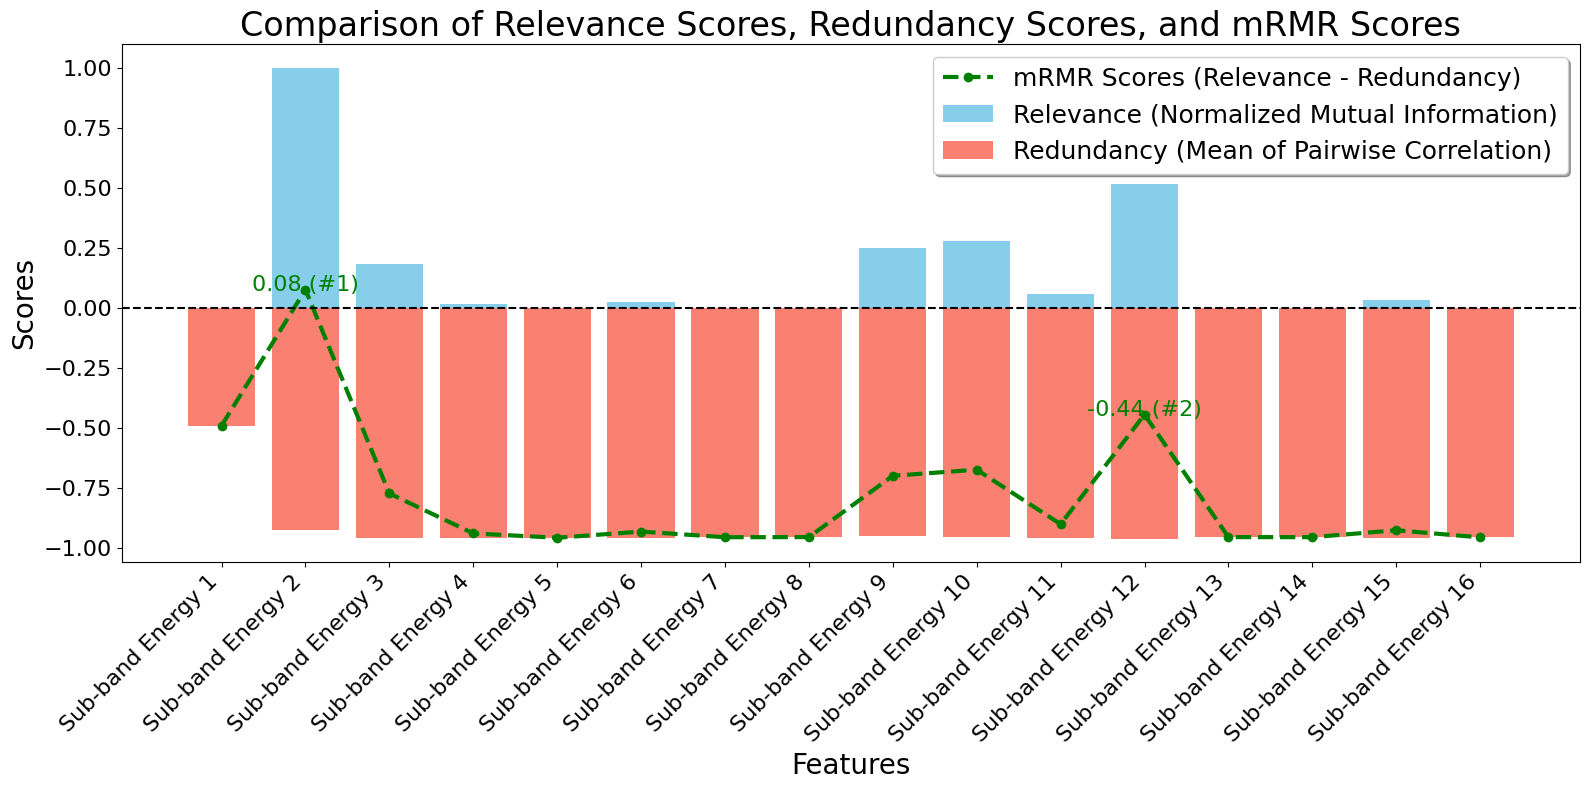

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Feature labels for x-axis
feature_labels = subband_energy_columns

# Enhanced visualization for MI, redundancy, and mRMR scores
plt.figure(figsize=(16, 8))

# Plot MI scores (positive contribution)
plt.bar(feature_labels, mi_scores_normalized, label="Relevance (Normalized Mutual Information)", color="skyblue")

# Plot redundancy scores (negative contribution)
plt.bar(feature_labels, -redundancy_scores, label="Redundancy (Mean of Pairwise Correlation)", color="salmon")

# Overlay the mRMR scores as a line plot
plt.plot(feature_labels, mrmr_scores, label="mRMR Scores (Relevance - Redundancy)", color="green", marker="o", linestyle="--", linewidth=3)

# Annotate only the top 3 mRMR scores with their rank
sorted_indices = np.argsort(mrmr_scores)[::-1]  # Indices of mRMR scores sorted in descending order
# top_rank_indices = sorted_indices[:3]  # Top 3 indices
top_rank_indices = sorted_indices[:2]  # Top 2 indices

for i in top_rank_indices:
    score = mrmr_scores[i]
    plt.text(
        i,  # x-coordinate
        # score + (0.03 if score > 0 else -0.03),  # Offset the y-coordinate slightly
        score + 0.06,  # Offset the y-coordinate slightly
        f"{score:.2f} (#{top_rank_indices.tolist().index(i) + 1})",  # Text label with mRMR score and rank
        color="green",  # Red text color for the top 3 annotations
        fontsize=16,
        ha="center",
        # va="bottom" if score > 0 else "top"  # Adjust position based on score
        va="top"
    )
    
# Customizing the plot
plt.title("Comparison of Relevance Scores, Redundancy Scores, and mRMR Scores", fontsize=24)
plt.xlabel("Features", fontsize=20)
plt.ylabel("Scores", fontsize=20)
plt.xticks(rotation=45, ha="right", fontsize=16)
plt.yticks(fontsize=16)
plt.axhline(0, color="black", linewidth=1.5, linestyle="--")

# Adjusting the legend with better font size and placement
handles, labels = plt.gca().get_legend_handles_labels()
unique_labels = []
unique_handles = []
for handle, label in zip(handles, labels):
    if label not in unique_labels:
        unique_labels.append(label)
        unique_handles.append(handle)
# plt.legend(unique_handles, unique_labels, loc='upper center', bbox_to_anchor=(1.15, 1.0), fancybox=True, shadow=True, fontsize=14)
plt.legend(unique_handles, unique_labels, loc='upper right', fancybox=True, shadow=True, fontsize=18)

# Tight layout for better spacing
plt.tight_layout()

# Save high-resolution images
plt.savefig("/nfs/turbo/med-kayvan-lab/Projects/PARDS/04-Results/PARDS_Risk/4-DTCWPT_and_mRMR/Relevance_Redundancy_mRMR_Comparison(top2).png", format='png', dpi=300)
plt.savefig("/nfs/turbo/med-kayvan-lab/Projects/PARDS/04-Results/PARDS_Risk/4-DTCWPT_and_mRMR/Relevance_Redundancy_mRMR_Comparison(top2).pdf", format='pdf', bbox_inches='tight')

# Display the plot
plt.show()


In [13]:
mi_scores_normalized

array([0.        , 1.        , 0.1839582 , 0.01886967, 0.        ,
       0.02489932, 0.        , 0.        , 0.24989463, 0.27914714,
       0.05828129, 0.51599969, 0.        , 0.        , 0.03177524,
       0.        ])

In [14]:
redundancy_scores

array([0.48961249, 0.92324875, 0.95536872, 0.95667694, 0.95593471,
       0.95507064, 0.95372116, 0.95312753, 0.94797335, 0.95176704,
       0.95754907, 0.95915789, 0.95317755, 0.95348848, 0.95647685,
       0.95423581])

In [15]:
mrmr_scores

array([-0.48961249,  0.07675125, -0.77141052, -0.93780727, -0.95593471,
       -0.93017132, -0.95372116, -0.95312753, -0.69807872, -0.6726199 ,
       -0.89926778, -0.4431582 , -0.95317755, -0.95348848, -0.92470161,
       -0.95423581])

Features set shape: (224, 8)
Target set shape: (224,)
below_7.5    186
above_7.5     38
Name: OSI_12th_category, dtype: int64

Results for Naive Bayes:
Best Hyperparameters: {}
Test Results: AUC = 0.82 (±0.06), AUPRC = 0.42 (±0.12), F1 = 0.33 (±0.09)

Results for Random Forest:
Best Hyperparameters: {'max_depth': None, 'n_estimators': 50}
Test Results: AUC = 0.86 (±0.02), AUPRC = 0.52 (±0.08), F1 = 0.55 (±0.10)

Results for SVM:
Best Hyperparameters: {'svc__C': 0.1, 'svc__degree': 2, 'svc__kernel': 'linear'}
Test Results: AUC = 0.83 (±0.04), AUPRC = 0.45 (±0.10), F1 = 0.17 (±0.17)

Results for Logistic Regression:
Best Hyperparameters: {'lr__C': 0.01, 'lr__penalty': 'l2'}
Test Results: AUC = 0.84 (±0.04), AUPRC = 0.46 (±0.10), F1 = 0.10 (±0.16)


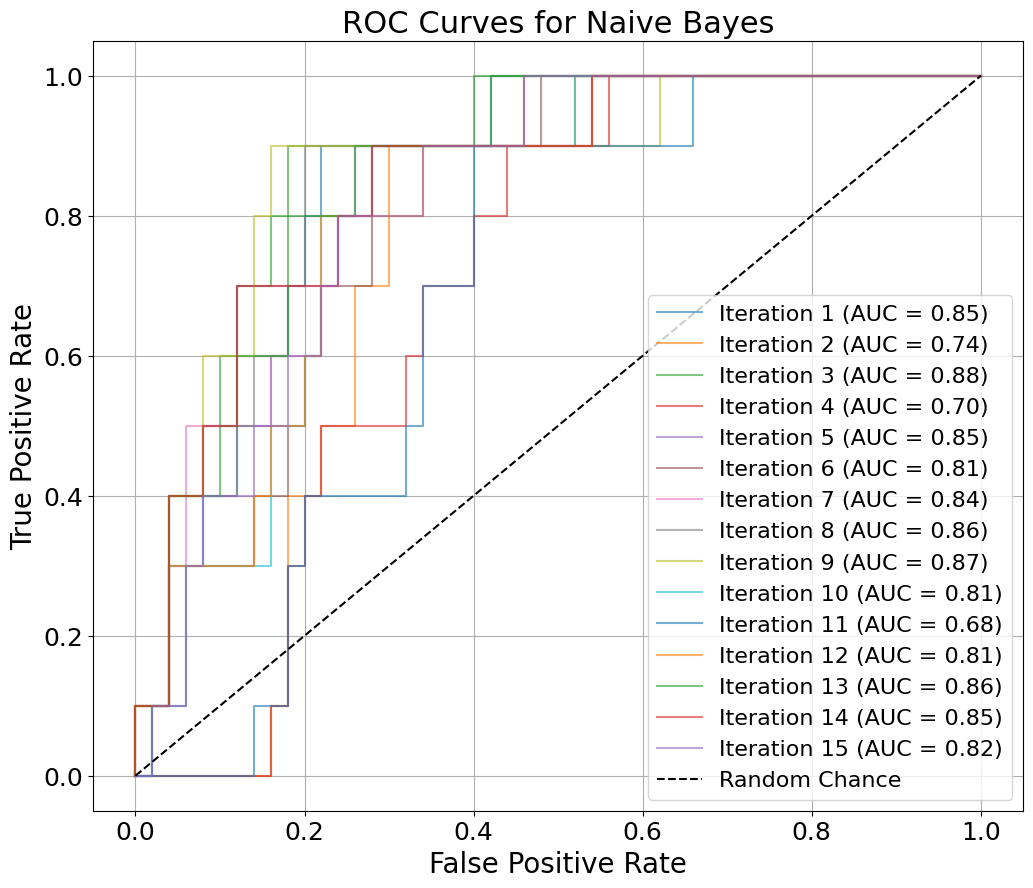

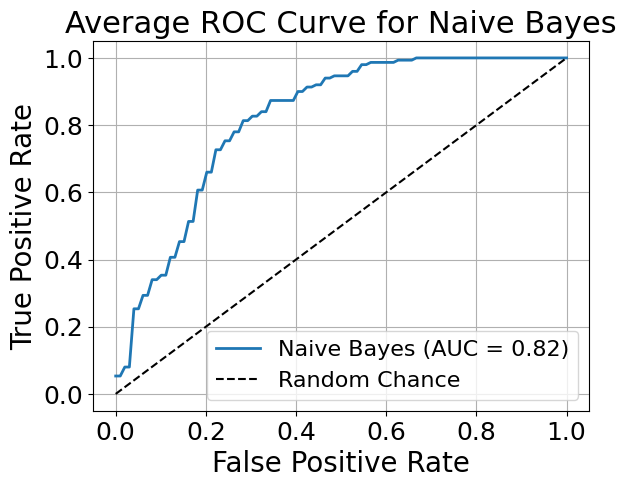

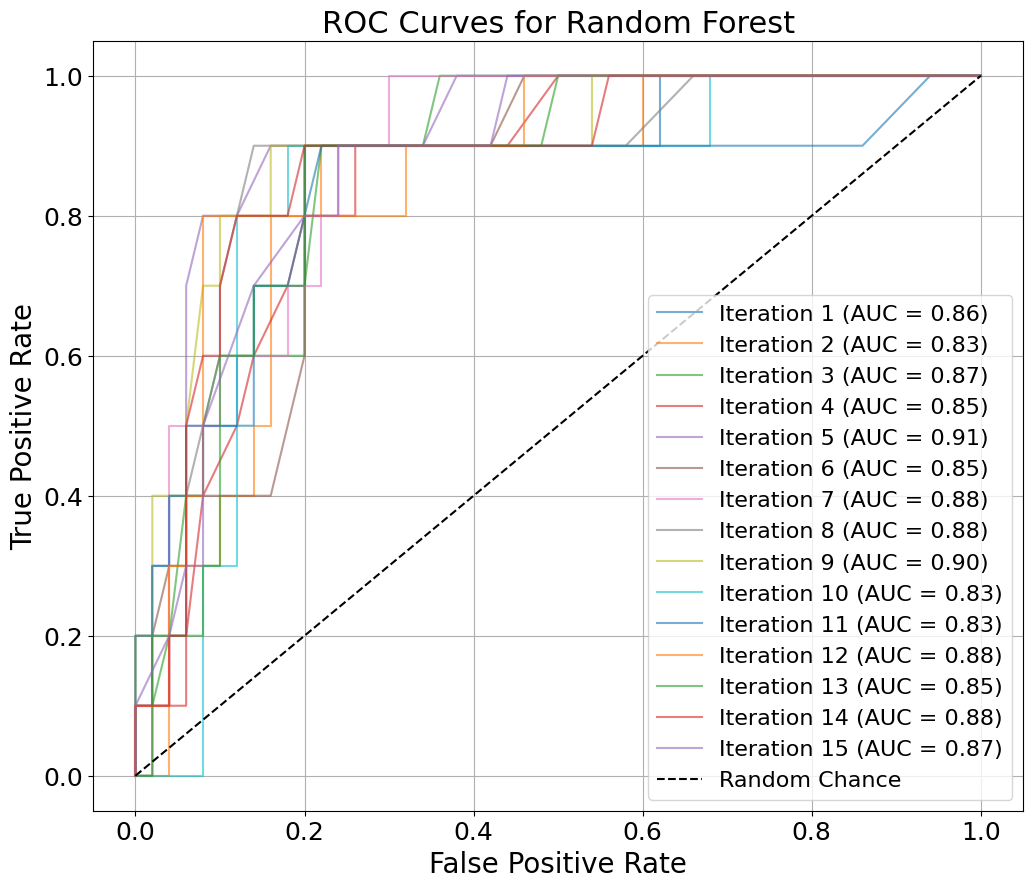

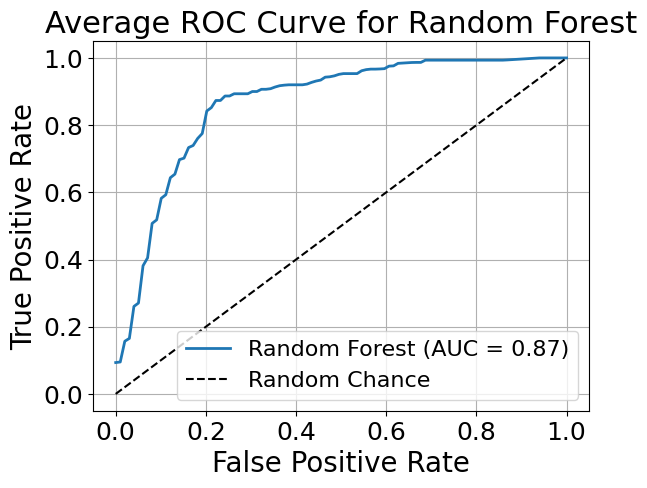

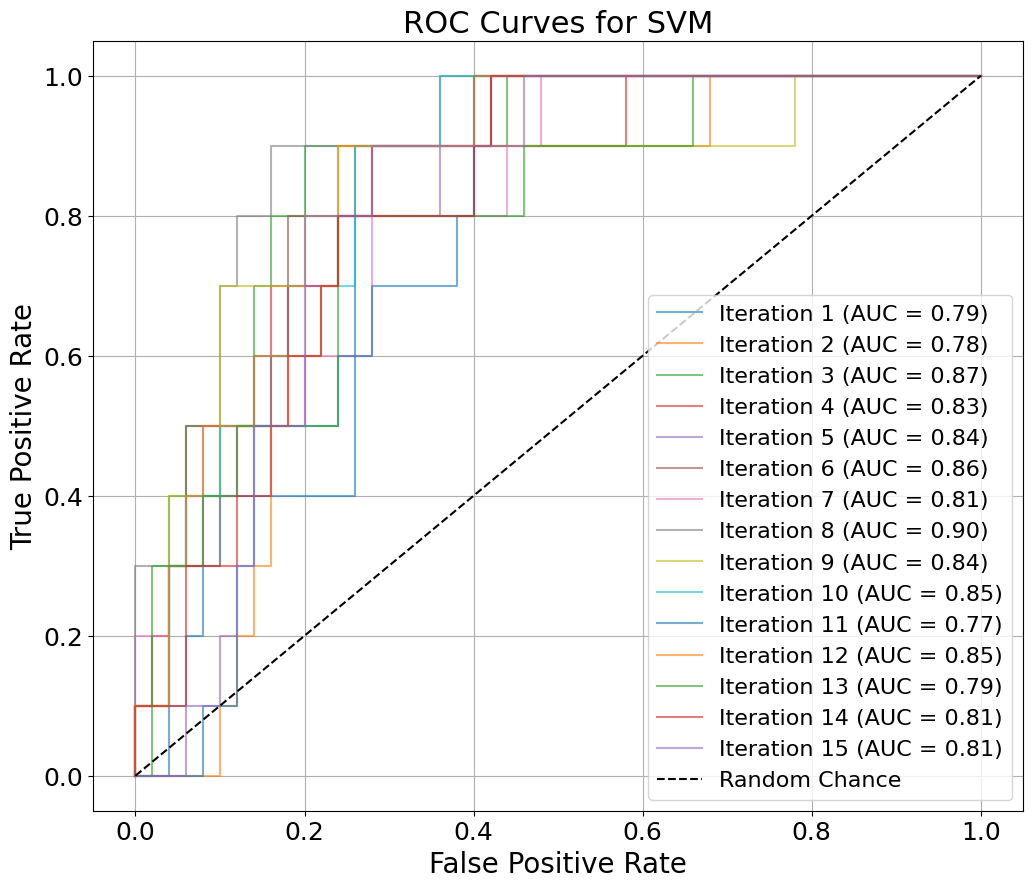

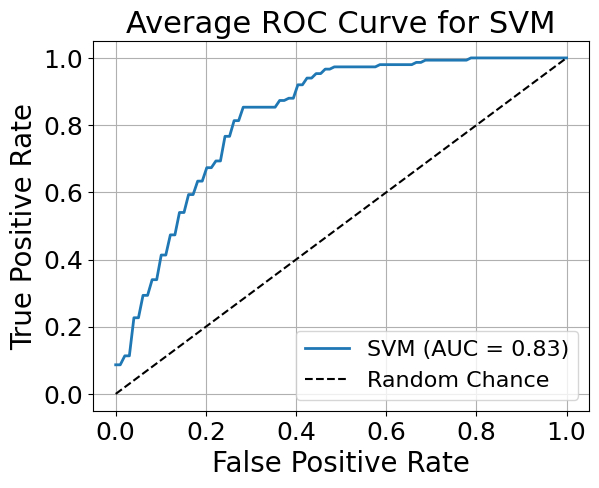

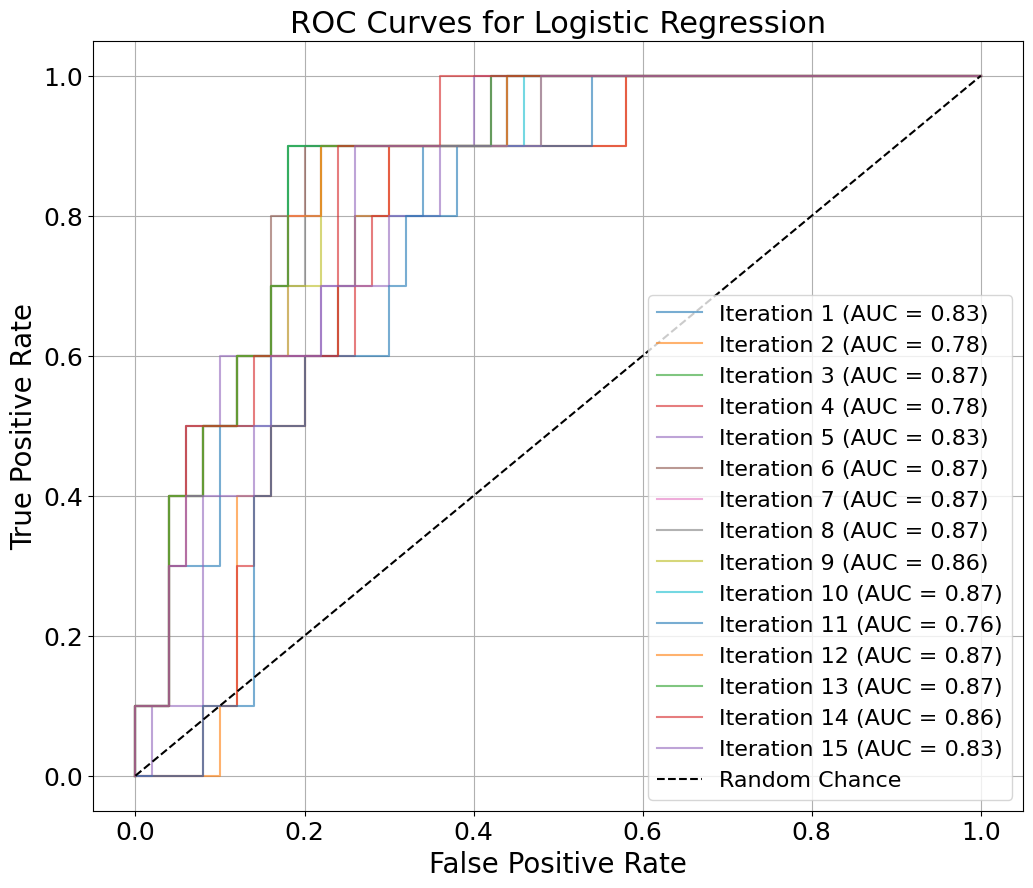

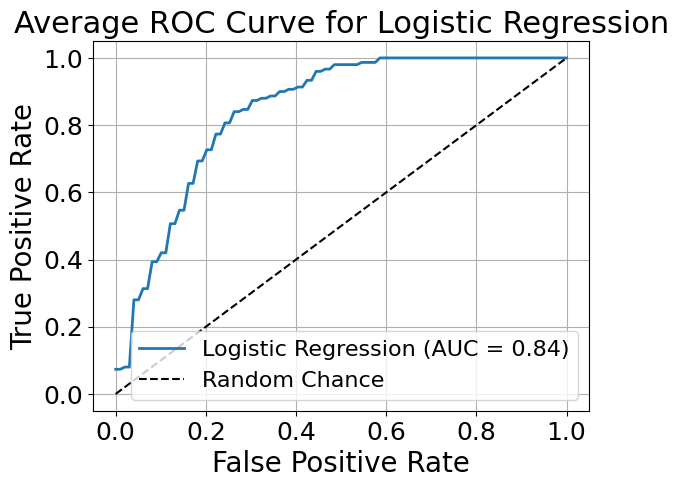

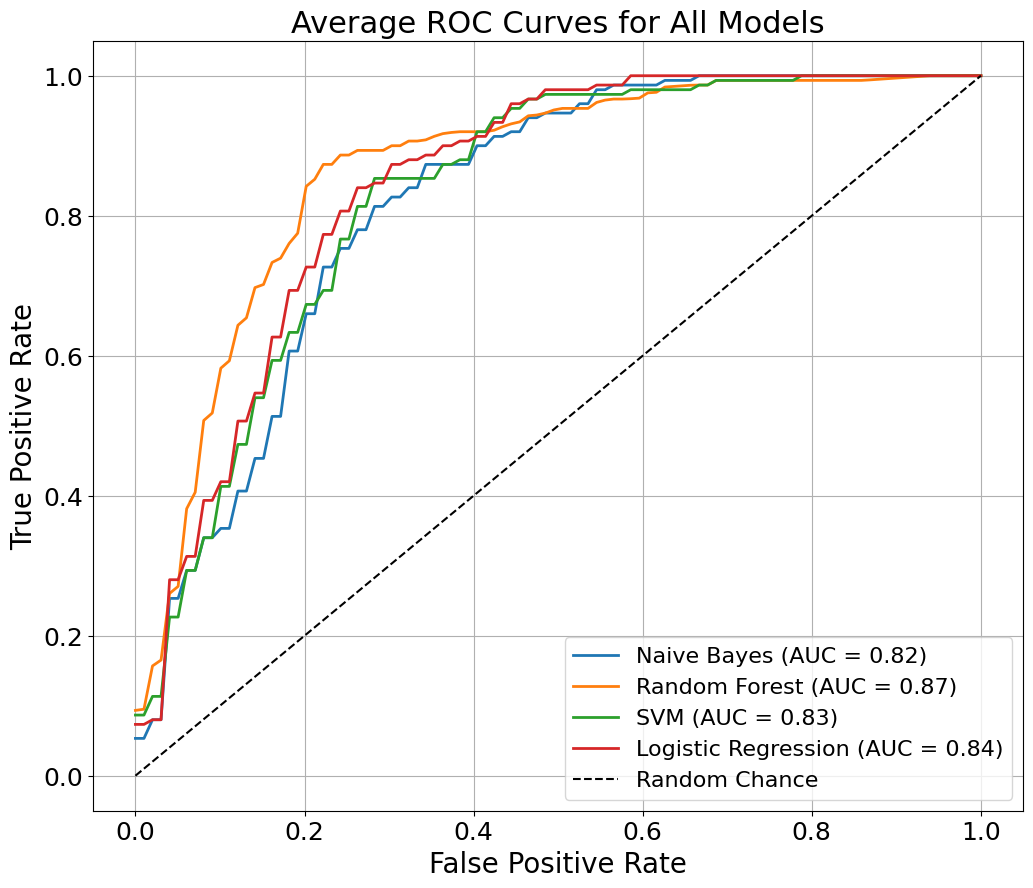

In [7]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedShuffleSplit, train_test_split, GridSearchCV
from sklearn.metrics import roc_auc_score, f1_score, precision_recall_curve, roc_curve, auc, confusion_matrix, make_scorer
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from collections import defaultdict
from sklearn.utils import shuffle
import matplotlib.pyplot as plt

# Load df_combined dataset from Sheet18
df_combined = pd.read_excel('/nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/TRAPPARDS/df_combined.xlsx', sheet_name='Sheet18')

##########################################################################################
# EHR features
# ehr_features = ['OSI_1st_avg']
# ehr_features = ['OSI_1st_mean', 'OSI_1st_std']
# ehr_features = ['OSI_1st_mean', 'OSI_1st_std', 'PIP_mean', 'PIP_sd', 'PEEP_mean', 'PEEP_sd', 'TV_mean(mL/Kg)', 'TV_std(mL/Kg)']
ehr_features = ['OSI_1st_avg', 'PIP_mean', 'PEEP_mean', 'TV_mean(mL/Kg)']

# Flow time-related features
# time_features = ['Mean Duration (s)', 'SD Duration (s)', 'Mean Time Difference (s)', 'SD Time Difference (s)']
time_features = ['Mean Duration (s)', 'Mean Time Difference (s)']

# Flow PC columns
pc_columns = [f"PC{i}" for i in range(1, 8)]  # PC1 to PC7

# Flow Sub-band Energy columns
subband_energy_columns = [f"Sub-band Energy {i}" for i in range(1, 17)]  # Sub-band Energy 1 to 16

# Normalized Energy columns
normalized_energy_columns = [f"Normalized Energy {i}" for i in range(1, 17)]  # Normalized Energy 1 to 16

# Mean Sub-band columns
mean_subband_columns = [f"Mean Sub-band {i}" for i in range(1, 17)]  # Mean Sub-band 1 to 16

# SD Sub-band columns
SD_subband_columns = [f"SD Sub-band {i}" for i in range(1, 17)]  # SD Sub-band 1 to 16

# mRMR top Sub-band columns
top_energy_columns = top_features

# Combine all features dynamically
features_columns = (
    ehr_features +
    time_features +
    # pc_columns  
    # subband_energy_columns
    # normalized_energy_columns
    # mean_subband_columns +
    # SD_subband_columns
    top_energy_columns
)

# # Print the resulting list of feature columns (for verification)
# print("Feature Columns:", features_columns)
###########################################################################################
target_column = 'OSI_12th_avg'

df_combined['OSI_1st_avg'] = df_combined['OSI_1st_avg'].round(1)
df_combined['OSI_12th_avg'] = df_combined['OSI_12th_avg'].round(1)

# Drop rows with NaNs in features or target columns
df_combined_cleaned = df_combined.dropna(subset=features_columns + [target_column])

# Create binary target column based on the new threshold
df_combined_cleaned = df_combined_cleaned.copy()  # Create a copy to avoid SettingWithCopyWarning
df_combined_cleaned['OSI_12th_category'] = np.where(df_combined_cleaned['OSI_12th_avg'] < 7.5, 'below_7.5', 'above_7.5')

# Extract features and target
features = df_combined_cleaned[features_columns]
target = df_combined_cleaned['OSI_12th_category']

# Check the dimensionality of the features, target, and new categorical target sets
print(f"Features set shape: {features.shape}")
print(f"Target set shape: {target.shape}")
print(df_combined_cleaned['OSI_12th_category'].value_counts())

# Manually update the target column to 0 or 1
target = target.map({'below_7.5': 0, 'above_7.5': 1})

# Helper function to compute AUPRC
def auprc(y_true, y_scores):
    precision, recall, _ = precision_recall_curve(y_true, y_scores[:, 1])
    return auc(recall, precision)

# Define classifiers and parameter grids
classifiers = {
    'Naive Bayes': (GaussianNB(), {}),
    'Random Forest': (RandomForestClassifier(),
                      {'n_estimators': [50, 100, 200], 'max_depth': [5, 10, None]}),
    'SVM': (Pipeline([('scaler', StandardScaler()), ('svc', SVC(probability=True))]),
            {'svc__C': [0.1, 1, 10], 'svc__kernel': ['linear', 'rbf', 'poly'], 'svc__degree': [2, 3]}),
    'Logistic Regression': (Pipeline([('scaler', StandardScaler()), ('lr', LogisticRegression(max_iter=500))]),
                            {'lr__C': [0.01, 0.1, 1, 10], 'lr__penalty': ['l2']})
}

# Stratify and split data into test and training sets
test_ratio = 60 / len(features)
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=test_ratio, stratify=target, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)  # Standardize X_train
X_test = scaler.transform(X_test)        # Standardize X_test

# Separate classes for resampling
class_0_indices = np.where(y_train == 0)[0]  # Mild class (e.g., below_7.5)
class_1_indices = np.where(y_train == 1)[0]  # Other class (e.g., above_7.5)

# Convert back to DataFrame for compatibility with .iloc
X_train = pd.DataFrame(X_train, columns=features.columns)
X_test = pd.DataFrame(X_test, columns=features.columns)

# Repeated resampling and validation
n_repeats = 15
metrics_results = defaultdict(list)
best_params = defaultdict(dict)

for repeat in range(n_repeats):
    # Resample 55 from class 0 and 25 from class 1
    class_0_sample = np.random.choice(class_0_indices, size=55, replace=False)
    class_1_sample = np.random.choice(class_1_indices, size=25, replace=False)

    # Combine sampled indices and shuffle them
    resample_indices = np.concatenate([class_0_sample, class_1_sample])
    resample_indices = shuffle(resample_indices, random_state=repeat)

    # Extract resampled training subset
    X_train_subset, y_train_subset = X_train.iloc[resample_indices], y_train.iloc[resample_indices]

    for model_name, (model, param_grid) in classifiers.items():
        # Hyperparameter tuning using cross-validation
        grid_search = GridSearchCV(model, param_grid, cv=5, scoring='roc_auc', refit=True, n_jobs=-1)
        grid_search.fit(X_train_subset, y_train_subset)

        # Save the best parameters
        best_params[model_name] = grid_search.best_params_

        # Test set evaluation
        best_model = grid_search.best_estimator_
        y_test_proba = best_model.predict_proba(X_test)
        y_test_pred = best_model.predict(X_test)

        # Compute metrics
        auc_score = roc_auc_score(y_test, y_test_proba[:, 1])
        auprc_score = auprc(y_test, y_test_proba)
        f1 = f1_score(y_test, y_test_pred)

        # Store results, including y_true and y_proba
        metrics_results[model_name].append({
            'AUC': auc_score,
            'AUPRC': auprc_score,
            'F1': f1,
            'y_true': y_test,
            'y_proba': y_test_proba
        })

# Compute mean and standard deviation for each metric
final_results = {}
for model_name, metrics_list in metrics_results.items():
    metrics_df = pd.DataFrame(metrics_list)
    final_results[model_name] = {
        'AUC': (metrics_df['AUC'].mean(), metrics_df['AUC'].std()),
        'AUPRC': (metrics_df['AUPRC'].mean(), metrics_df['AUPRC'].std()),
        'F1': (metrics_df['F1'].mean(), metrics_df['F1'].std())
    }

# Print results
for model_name, metrics in final_results.items():
    print(f"\nResults for {model_name}:")
    print(f"Best Hyperparameters: {best_params[model_name]}")
    print(f"Test Results: AUC = {metrics['AUC'][0]:.2f} (±{metrics['AUC'][1]:.2f}), "
          f"AUPRC = {metrics['AUPRC'][0]:.2f} (±{metrics['AUPRC'][1]:.2f}), "
          f"F1 = {metrics['F1'][0]:.2f} (±{metrics['F1'][1]:.2f})")

# Define the save path for the plots
save_path = "/nfs/turbo/med-kayvan-lab/Projects/PARDS/04-Results/PARDS_Risk/6-ClassificationModels/"

def plot_individual_roc_curves(metrics_results, model_name):
    plt.figure(figsize=(12, 10))  # Increased figure size
    for i, result in enumerate(metrics_results[model_name]):
        fpr, tpr, _ = roc_curve(result['y_true'], result['y_proba'][:, 1])
        plt.plot(fpr, tpr, label=f'Iteration {i+1} (AUC = {auc(fpr, tpr):.2f})', alpha=0.6)
    plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
    plt.title(f'ROC Curves for {model_name}', fontsize=22)
    plt.xlabel('False Positive Rate', fontsize=20)
    plt.ylabel('True Positive Rate', fontsize=20)
    plt.legend(fontsize=16)
    plt.grid(True)
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    
    plt.savefig(f"{save_path}ROC_Curves_{model_name}.png", format='png', dpi=300)
    plt.savefig(f"{save_path}ROC_Curves_{model_name}.pdf", format='pdf', bbox_inches='tight')
    
    plt.show()

def plot_average_roc_curve(metrics_results, model_name):
    mean_fpr = np.linspace(0, 1, 100)
    tprs = []
    for result in metrics_results[model_name]:
        fpr, tpr, _ = roc_curve(result['y_true'], result['y_proba'][:, 1])
        tprs.append(np.interp(mean_fpr, fpr, tpr))
    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0
    plt.plot(mean_fpr, mean_tpr, label=f'{model_name} (AUC = {auc(mean_fpr, mean_tpr):.2f})', linewidth=2)
    plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
    plt.title(f'Average ROC Curve for {model_name}', fontsize=22)
    plt.xlabel('False Positive Rate', fontsize=20)
    plt.ylabel('True Positive Rate', fontsize=20)
    plt.legend(fontsize=16)
    plt.grid(True)
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    
    plt.savefig(f"{save_path}Average_ROC_Curve_{model_name}.png", format='png', dpi=300)
    plt.savefig(f"{save_path}Average_ROC_Curve_{model_name}.pdf", format='pdf', bbox_inches='tight')
    
    plt.show()

def plot_all_models_roc_curves(metrics_results, model_names):
    plt.figure(figsize=(12, 10))  # Increased figure size
    for model_name in model_names:
        mean_fpr = np.linspace(0, 1, 100)
        tprs = []
        for result in metrics_results[model_name]:
            fpr, tpr, _ = roc_curve(result['y_true'], result['y_proba'][:, 1])
            tprs.append(np.interp(mean_fpr, fpr, tpr))
        mean_tpr = np.mean(tprs, axis=0)
        mean_tpr[-1] = 1.0
        plt.plot(mean_fpr, mean_tpr, label=f'{model_name} (AUC = {auc(mean_fpr, mean_tpr):.2f})', linewidth=2)
    plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
    plt.title('Average ROC Curves for All Models', fontsize=22)
    plt.xlabel('False Positive Rate', fontsize=20)
    plt.ylabel('True Positive Rate', fontsize=20)
    plt.legend(fontsize=16)
    plt.grid(True)
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    
    plt.savefig(f"{save_path}All_Models_ROC_Curves.png", format='png', dpi=300)
    plt.savefig(f"{save_path}All_Models_ROC_Curves.pdf", format='pdf', bbox_inches='tight')
    
    plt.show()

# Plot results for individual models and save
for model_name in classifiers.keys():
    plot_individual_roc_curves(metrics_results, model_name)
    plot_average_roc_curve(metrics_results, model_name)

# Plot results for all models combined and save
plot_all_models_roc_curves(metrics_results, classifiers.keys())

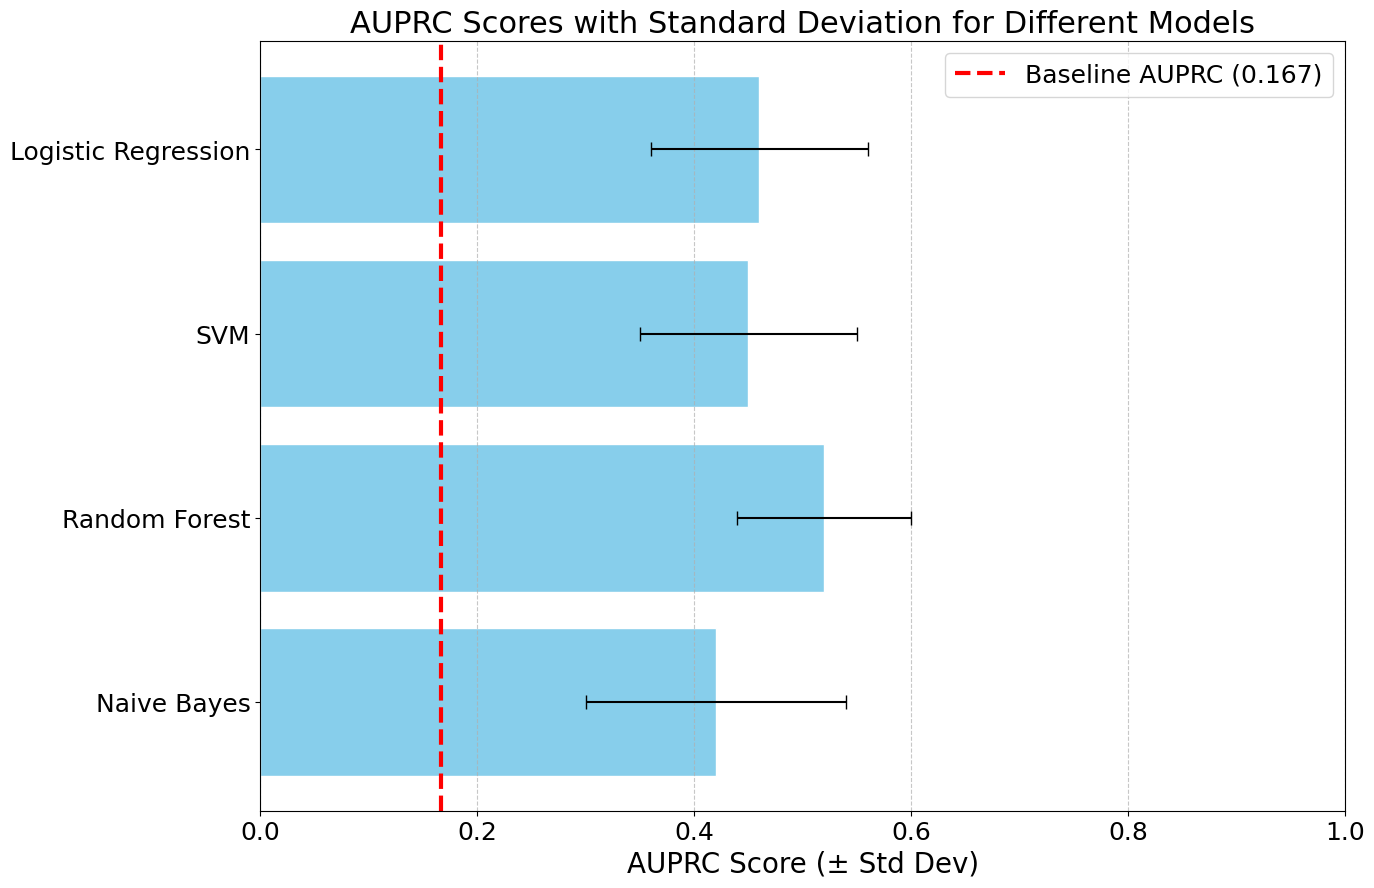

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Updated Data
models = ["Naive Bayes", "Random Forest", "SVM", "Logistic Regression"]
auprc_scores = [0.42, 0.52, 0.45, 0.46]  # Updated AUPRC values
auprc_std = [0.12, 0.08, 0.10, 0.10]  # Updated standard deviations

# Plotting
plt.figure(figsize=(14, 10))  # Further increased figure size for better visibility
y_pos = np.arange(len(models))
plt.barh(y_pos, auprc_scores, xerr=auprc_std, capsize=5, color='skyblue', edgecolor='white')

# Baseline AUPRC
baseline = 0.167
plt.axvline(x=baseline, color='red', linestyle='--', linewidth=3, label='Baseline AUPRC (0.167)')

# Formatting with larger font sizes
plt.yticks(y_pos, models, fontsize=18)
plt.xlabel("AUPRC Score (± Std Dev)", fontsize=20)
plt.title("AUPRC Scores with Standard Deviation for Different Models", fontsize=22)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.xlim(0, 1)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=18)

# Save the figure in high resolution
plt.savefig("/nfs/turbo/med-kayvan-lab/Projects/PARDS/04-Results/PARDS_Risk/6-ClassificationModels/AUPRC_Scores.png", format='png', dpi=300)
plt.savefig("/nfs/turbo/med-kayvan-lab/Projects/PARDS/04-Results/PARDS_Risk/6-ClassificationModels/AUPRC_Scores.pdf", format='pdf', bbox_inches='tight')

# Display plot
plt.show()


Regression Models

In [3]:
# Import necessary libraries
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.linear_model import Ridge, Lasso
from sklearn.svm import SVR  # Import the correct model for regression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
# Load df_combined dataset from Sheet18
df_combined = pd.read_excel('/nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/TRAPPARDS/df_combined.xlsx', sheet_name='Sheet18')

##########################################################################################
# The relevant feature and target columns
features_columns = ['OSI_1st_avg', 'PIP_mean', 'PEEP_mean', 'TV_mean(mL/Kg)',
                    'Mean Duration (s)', 'Mean Time Difference (s)',
                    'Sub-band Energy 2', 'Sub-band Energy 12']
###########################################################################################
target_column = 'OSI_12th_avg'

# Round the OSI_1st_avg and OSI_12th_avg columns to one decimal place
df_combined['OSI_1st_avg'] = df_combined['OSI_1st_avg'].round(1)
df_combined['OSI_12th_avg'] = df_combined['OSI_12th_avg'].round(1)

# Drop rows where any of the features or target columns have NaN values
df_combined_cleaned = df_combined.dropna(subset=features_columns + [target_column])

# Select feature set and target set (OSI_12th_avg)
features = df_combined_cleaned[features_columns]
target = df_combined_cleaned[target_column]

# Check the dimensionality of the features and target sets
print(f"Features set shape: {features.shape}")
print(f"Target set shape: {target.shape}")

Features set shape: (224, 8)
Target set shape: (224,)


Training Ridge Regression...
Ridge Regression - Best Hyperparameters: {'alpha': 10}
Ridge Regression - Mean R² (CV): 0.27, Std R² (CV): 0.11, Adjusted R² (CV): 0.24
Ridge Regression - Mean RMSE (CV): 2.35, Std RMSE (CV): 0.56
Ridge Regression - Mean MAE (CV): 1.60, Std MAE (CV): 0.32
Ridge Regression - R² (Test): 0.24, Adjusted R² (Test): 0.07
Ridge Regression - RMSE (Test): 2.42
Ridge Regression - MAE (Test): 1.70


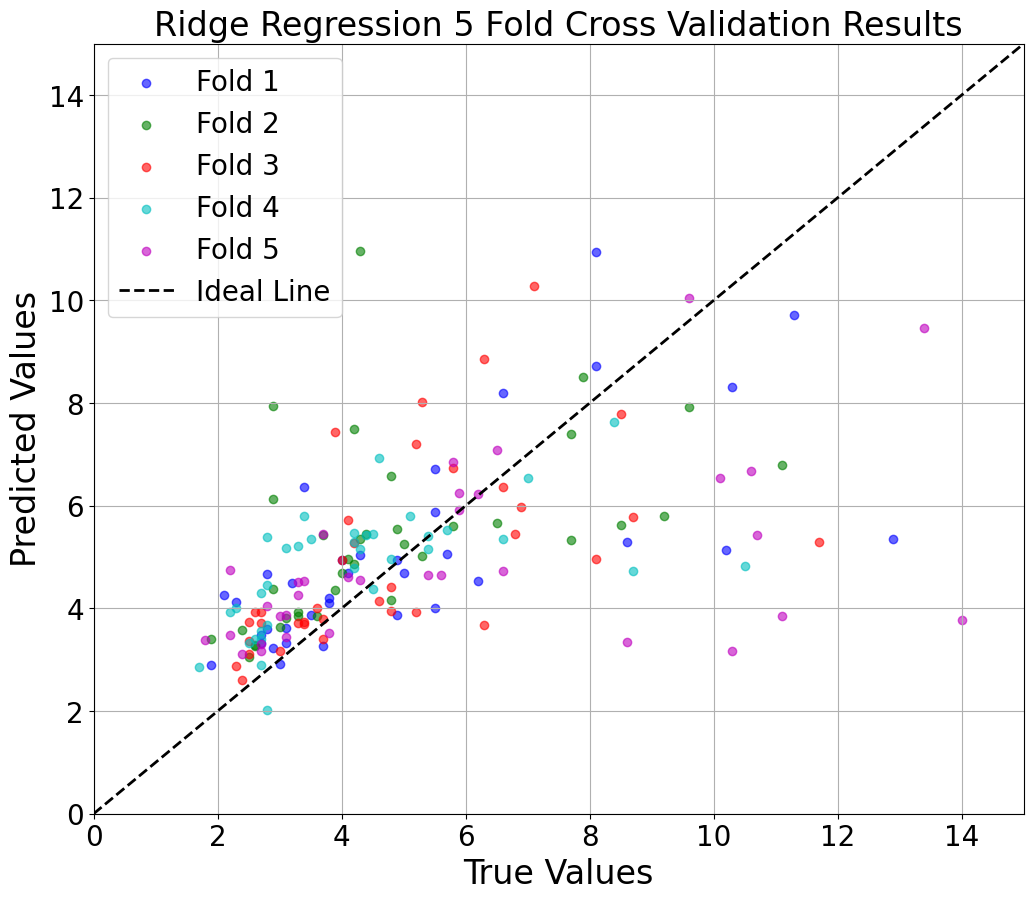

Training Lasso Regression...
Lasso Regression - Best Hyperparameters: {'alpha': 0.1}
Lasso Regression - Mean R² (CV): 0.27, Std R² (CV): 0.13, Adjusted R² (CV): 0.24
Lasso Regression - Mean RMSE (CV): 2.36, Std RMSE (CV): 0.59
Lasso Regression - Mean MAE (CV): 1.60, Std MAE (CV): 0.35
Lasso Regression - R² (Test): 0.25, Adjusted R² (Test): 0.08
Lasso Regression - RMSE (Test): 2.41
Lasso Regression - MAE (Test): 1.74


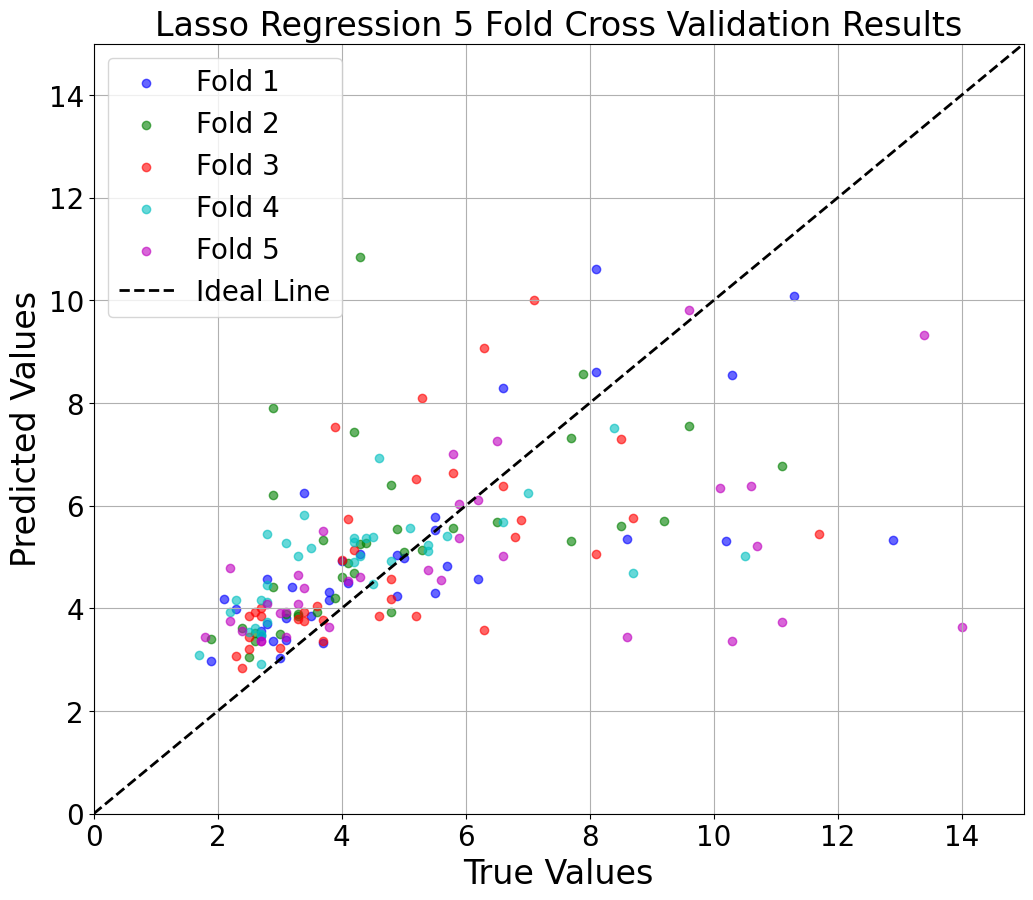

Training SVM (Linear)...
SVM (Linear) - Best Hyperparameters: {'svr__C': 0.1, 'svr__epsilon': 0.5}
SVM (Linear) - Mean R² (CV): 0.28, Std R² (CV): 0.11, Adjusted R² (CV): 0.24
SVM (Linear) - Mean RMSE (CV): 2.36, Std RMSE (CV): 0.63
SVM (Linear) - Mean MAE (CV): 1.48, Std MAE (CV): 0.38
SVM (Linear) - R² (Test): 0.19, Adjusted R² (Test): 0.01
SVM (Linear) - RMSE (Test): 2.50
SVM (Linear) - MAE (Test): 1.80


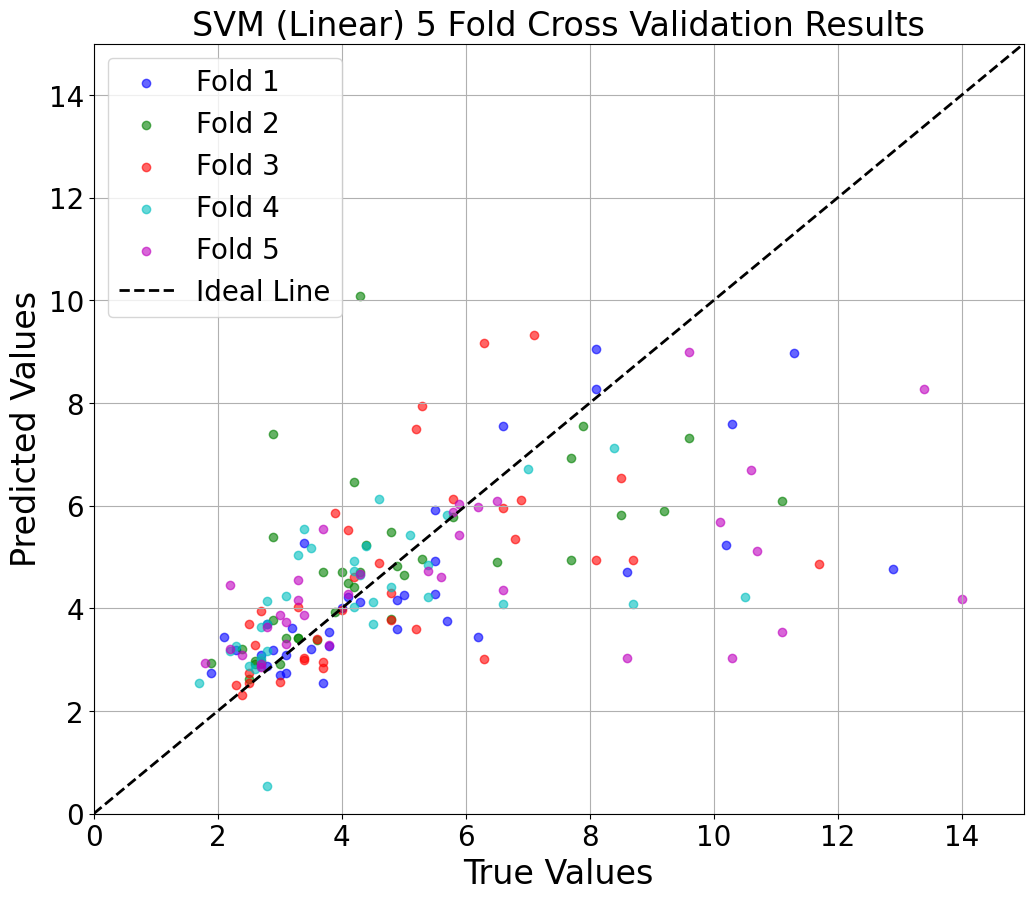

Training SVM (RBF)...
SVM (RBF) - Best Hyperparameters: {'svr__C': 10, 'svr__epsilon': 0.5, 'svr__gamma': 'scale'}
SVM (RBF) - Mean R² (CV): 0.29, Std R² (CV): 0.12, Adjusted R² (CV): 0.25
SVM (RBF) - Mean RMSE (CV): 2.37, Std RMSE (CV): 0.70
SVM (RBF) - Mean MAE (CV): 1.54, Std MAE (CV): 0.48
SVM (RBF) - R² (Test): 0.19, Adjusted R² (Test): 0.01
SVM (RBF) - RMSE (Test): 2.50
SVM (RBF) - MAE (Test): 1.90


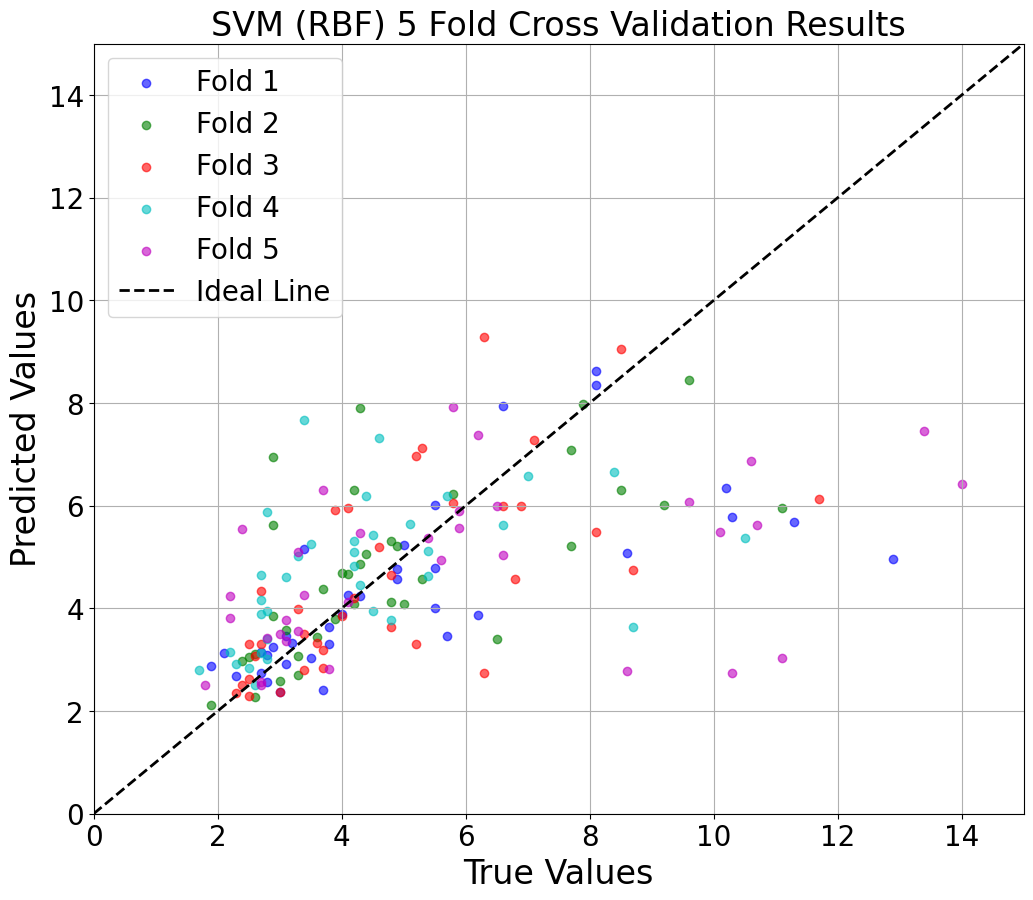

Training SVM (Poly)...
SVM (Poly) - Best Hyperparameters: {'svr__C': 0.1, 'svr__degree': 2, 'svr__epsilon': 0.5, 'svr__gamma': 'auto'}
SVM (Poly) - Mean R² (CV): -0.09, Std R² (CV): 0.14, Adjusted R² (CV): -0.15
SVM (Poly) - Mean RMSE (CV): 2.91, Std RMSE (CV): 0.74
SVM (Poly) - Mean MAE (CV): 2.04, Std MAE (CV): 0.48
SVM (Poly) - R² (Test): -0.12, Adjusted R² (Test): -0.37
SVM (Poly) - RMSE (Test): 2.94
SVM (Poly) - MAE (Test): 2.18


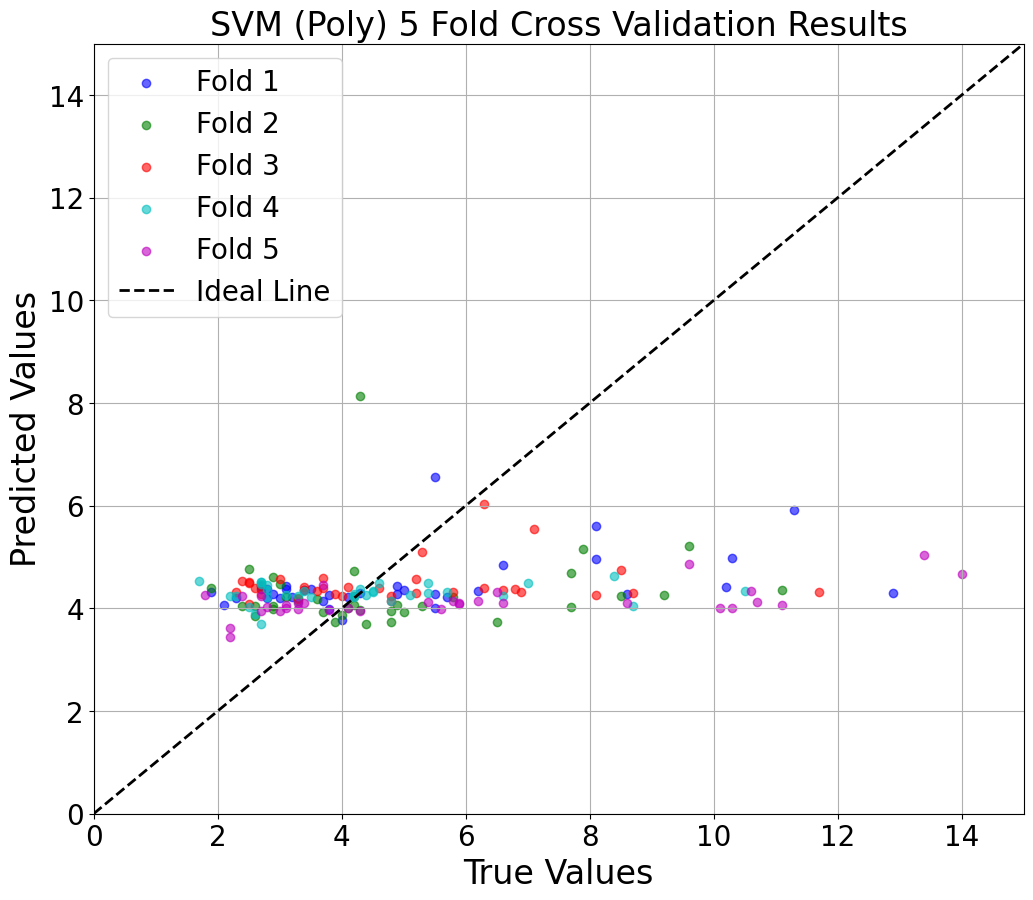


Summary of Results:
Ridge Regression:
  Best Hyperparameters: {'alpha': 10}
  R² Mean (CV): 0.27
  R² Std (CV): 0.11
Lasso Regression:
  Best Hyperparameters: {'alpha': 0.1}
  R² Mean (CV): 0.27
  R² Std (CV): 0.13
SVM (Linear):
  Best Hyperparameters: {'svr__C': 0.1, 'svr__epsilon': 0.5}
  R² Mean (CV): 0.28
  R² Std (CV): 0.11
SVM (RBF):
  Best Hyperparameters: {'svr__C': 10, 'svr__epsilon': 0.5, 'svr__gamma': 'scale'}
  R² Mean (CV): 0.29
  R² Std (CV): 0.12
SVM (Poly):
  Best Hyperparameters: {'svr__C': 0.1, 'svr__degree': 2, 'svr__epsilon': 0.5, 'svr__gamma': 'auto'}
  R² Mean (CV): -0.09
  R² Std (CV): 0.14


In [7]:
# Perform Train-Test Split with 80% training and 20% testing
X_train_scaled, X_test_scaled, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# Standardize features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_scaled)
X_test_scaled = scaler.transform(X_test_scaled)

# Define the models with SVR instead of SVC
models = {
    'Ridge Regression': Ridge(),
    'Lasso Regression': Lasso(),
    'SVM (Linear)': Pipeline([('scaler', StandardScaler()), ('svr', SVR(kernel='linear'))]),
    'SVM (RBF)': Pipeline([('scaler', StandardScaler()), ('svr', SVR(kernel='rbf'))]),
    'SVM (Poly)': Pipeline([('scaler', StandardScaler()), ('svr', SVR(kernel='poly'))])
}

# Hyperparameter grid for SVM and other models
param_grid = {
    'Ridge Regression': {'alpha': [0.1, 1, 10, 100]},
    'Lasso Regression': {'alpha': [0.1, 1, 10, 100]},
    'SVM (Linear)': {'svr__C': [0.1, 1, 10], 'svr__epsilon': [0.01, 0.1, 0.5]},
    'SVM (RBF)': {'svr__C': [0.1, 1, 10], 'svr__epsilon': [0.01, 0.1, 0.5], 'svr__gamma': ['scale', 'auto']},
    'SVM (Poly)': {'svr__C': [0.1, 1, 10], 'svr__epsilon': [0.01, 0.1, 0.5], 'svr__degree': [2, 3, 4], 'svr__gamma': ['scale', 'auto']}
}

# Define save path for the plots
save_path = "/nfs/turbo/med-kayvan-lab/Projects/PARDS/04-Results/PARDS_Risk/7-RegressionModels/"

def plot_cv_results(cv_folds, model_name, r2_mean, adj_r2, r2_std, save_path, subplot_idx=1):
    """
    Function to plot scatter plot for cross-validation results and save the plots.
    
    Arguments:
    - cv_folds: List of tuples containing actual and predicted values for each fold
    - model_name: Name of the model
    - r2_mean: Mean R² score
    - adj_r2: Adjusted R² score
    - r2_std: Standard deviation of R² scores
    - save_path: Path to save the plots
    - subplot_idx: Index for subplot
    """
    plt.figure(figsize=(12, 10))  # Further increased figure size
    colors = ['b', 'g', 'r', 'c', 'm']  # Colors for each fold
    
    # Find min and max of true and predicted values across all folds to ensure consistent axis limits
    all_true_values = []
    all_pred_values = []
    
    for fold_idx, (y_true, y_pred) in enumerate(cv_folds):
        all_true_values.extend(y_true)
        all_pred_values.extend(y_pred)
    
    min_value = min(min(all_true_values), min(all_pred_values))
    max_value = max(max(all_true_values), max(all_pred_values))
    
    for fold_idx, (y_true, y_pred) in enumerate(cv_folds):
        plt.scatter(
            y_true, y_pred, color=colors[fold_idx % len(colors)], alpha=0.6, label=f'Fold {fold_idx+1}'
        )
    
    plt.plot(
        [0, 15], [0, 15],
        color='k', linestyle='--', linewidth=2, label='Ideal Line'
    )
    
    plt.title(
        f'{model_name} 5 Fold Cross Validation Results',
        fontsize=24  # Enlarged title font
    )
    plt.xlabel('True Values', fontsize=24)
    plt.ylabel('Predicted Values', fontsize=24)
    plt.legend(fontsize=20)
    plt.grid(True)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    
    # Set consistent axis limits
    plt.xlim(0, 15)
    plt.ylim(0, 15)
    
    # Save the plot
    file_base = f"{save_path}{model_name.replace(' ', '_')}_CV_Results"
    # plt.savefig(f"{file_base}.png", format='png', dpi=300, bbox_inches='tight')
    plt.savefig(f"{file_base}.pdf", format='pdf', bbox_inches='tight')
    plt.show()

# Store results
r2_results = {}

# Perform GridSearch and 5-fold cross-validation
for model_name, model in models.items():
    print(f"Training {model_name}...")
    
    # GridSearchCV for hyperparameter tuning
    grid_search = GridSearchCV(model, param_grid[model_name], cv=5, scoring='neg_mean_squared_error')
    grid_search.fit(X_train_scaled, y_train)
    
    best_model = grid_search.best_estimator_
    best_params = grid_search.best_params_  # Store the best hyperparameters
    
    # Perform cross-validation to calculate R², RMSE, and MAE
    cv_folds = []
    r2_fold_scores = []
    rmse_fold_scores = []
    mae_fold_scores = []
    
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    
    for train_idx, val_idx in kf.split(X_train_scaled):
        X_fold_train, X_fold_val = X_train_scaled[train_idx], X_train_scaled[val_idx]
        y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        best_model.fit(X_fold_train, y_fold_train)
        y_pred = best_model.predict(X_fold_val)
        
        # Calculate R², RMSE, and MAE for each fold
        r2_fold = r2_score(y_fold_val, y_pred)
        rmse_fold = np.sqrt(mean_squared_error(y_fold_val, y_pred))
        mae_fold = mean_absolute_error(y_fold_val, y_pred)
        
        r2_fold_scores.append(r2_fold)
        rmse_fold_scores.append(rmse_fold)
        mae_fold_scores.append(mae_fold)
        
        cv_folds.append((y_fold_val, y_pred))
    
    # Calculate mean and std of R², RMSE, and MAE scores for CV
    r2_mean = np.mean(r2_fold_scores)
    r2_std = np.std(r2_fold_scores)
    rmse_mean = np.mean(rmse_fold_scores)
    rmse_std = np.std(rmse_fold_scores)
    mae_mean = np.mean(mae_fold_scores)
    mae_std = np.std(mae_fold_scores)
    
    # Calculate Adjusted R² for CV
    n = len(y_train)  # Number of samples
    p = X_train_scaled.shape[1]  # Number of features
    adj_r2 = 1 - (1 - r2_mean) * (n - 1) / (n - p - 1)
    
    print(f"{model_name} - Best Hyperparameters: {best_params}")
    print(f"{model_name} - Mean R² (CV): {r2_mean:.2f}, Std R² (CV): {r2_std:.2f}, Adjusted R² (CV): {adj_r2:.2f}")
    print(f"{model_name} - Mean RMSE (CV): {rmse_mean:.2f}, Std RMSE (CV): {rmse_std:.2f}")
    print(f"{model_name} - Mean MAE (CV): {mae_mean:.2f}, Std MAE (CV): {mae_std:.2f}")
    
    # Calculate R², Adjusted R², RMSE, and MAE for the test set
    y_test_pred = best_model.predict(X_test_scaled)
    
    r2_test = r2_score(y_test, y_test_pred)
    rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
    mae_test = mean_absolute_error(y_test, y_test_pred)
    
    adj_r2_test = 1 - (1 - r2_test) * (len(y_test) - 1) / (len(y_test) - X_test_scaled.shape[1] - 1)
    
    print(f"{model_name} - R² (Test): {r2_test:.2f}, Adjusted R² (Test): {adj_r2_test:.2f}")
    print(f"{model_name} - RMSE (Test): {rmse_test:.2f}")
    print(f"{model_name} - MAE (Test): {mae_test:.2f}")
    
    # Store results
    r2_results[model_name] = {
        'Best Hyperparameters': best_params,
        'R² Mean (CV)': round(r2_mean, 2),
        'R² Std (CV)': round(r2_std, 2),
        'Adjusted R² (CV)': round(adj_r2, 2),
        'RMSE Mean (CV)': round(rmse_mean, 2),
        'RMSE Std (CV)': round(rmse_std, 2),
        'MAE Mean (CV)': round(mae_mean, 2),
        'MAE Std (CV)': round(mae_std, 2),
        'R² (Test)': round(r2_test, 2),
        'Adjusted R² (Test)': round(adj_r2_test, 2),
        'RMSE (Test)': round(rmse_test, 2),
        'MAE (Test)': round(mae_test, 2)
    }
    
    # Example usage of the function:
    # plot_cv_results(cv_folds, model_name, r2_mean, adj_r2, r2_std, subplot_idx=1)
    plot_cv_results(cv_folds, model_name, r2_mean, adj_r2, r2_std, save_path)

# Print summary of results
print("\nSummary of Results:")
for model_name, scores in r2_results.items():
    print(f"{model_name}:")
    print(f"  Best Hyperparameters: {scores['Best Hyperparameters']}")
    print(f"  R² Mean (CV): {scores['R² Mean (CV)']:.2f}")
    print(f"  R² Std (CV): {scores['R² Std (CV)']:.2f}")